# 🧬 The Clustering Masterclass: K-Means & Hierarchical
Welcome to the second pillar of **Unsupervised Learning**.

In PCA, we crushed 20,000 dimensions down to 2 axes so we could physically see our data.
In **Clustering**, we let the math autonomously discover "Families" or "Groups" inside our data without us telling it the answers.

### The Biological Use Case
Imagine you run a single-cell RNA sequencing experiment on 5,000 unknown cells. You don't know what types of cells they are. If you group them by their gene expression, the math will naturally cluster the T-Cells together, the B-Cells together, and the Macrophages together.
---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="darkgrid")
print("Libraries loaded. Ready for Clustering!")


Libraries loaded. Ready for Clustering!


## 🎯 Part 1: K-Means Clustering

**The Intuition:**
You have a giant cloud of data points. You suspect there are `K` distinct species of bacteria in the sample. How does K-Means find them?

**The Algorithm (Expectation-Maximization):**
1. **Initialize:** The AI throws `K` random "Centroids" (center points) into the graph.
2. **Expectation (Assign):** Every single bacteria cell calculates its Euclidean distance (straight line) to all `K` centroids. It joins the team of the closest one.
3. **Maximization (Move):** Now that teams are formed, the Centroid physically moves itself to the exact mathematical Mean (average coordinates) of all the cells on its team.
4. **Loop:** Repeat steps 2 and 3 until the Centroids stop moving. The clusters are now perfectly balanced!


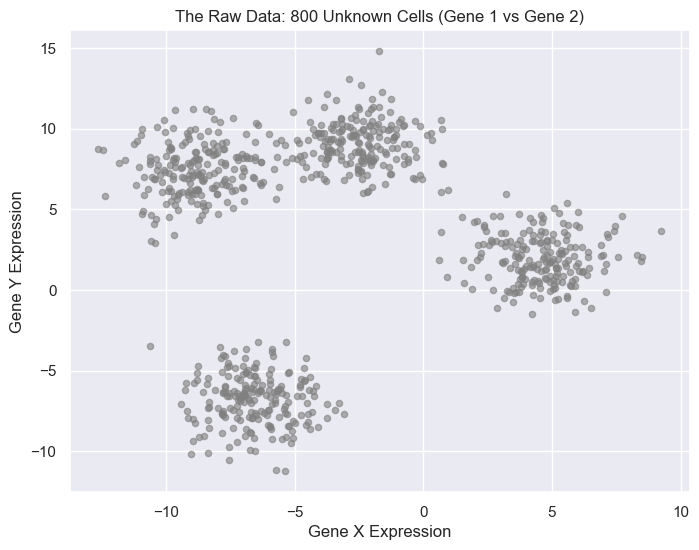

In [2]:
# Let's synthesize 4 distinct unknown cell types based on 2 Gene Expressions
X, true_labels = make_blobs(n_samples=800, centers=4, cluster_std=1.5, random_state=42)

# Remember, in REAL unsupervised learning, you DO NOT have true_labels.
plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], s=20, color="gray", alpha=0.6)
plt.title("The Raw Data: 800 Unknown Cells (Gene 1 vs Gene 2)")
plt.xlabel("Gene X Expression")
plt.ylabel("Gene Y Expression")
plt.show()


### 📉 Finding the magic number 'K': The Elbow Method
In the graph above, humans might easily guess there are 4 main clusters. But how does the AI know?

We calculate **Inertia** (Within-Cluster Sum of Squares). 
$$ \text{Inertia} = \sum_{i=1}^{n} (x_i - C_k)^2 $$
*Translation: How tightly packed are the clusters? We want the distance between cells and their assigned centroid to be as small as possible.*

If we run a `for-loop` testing $K=1$ through $10$, Inertia will initially drop massively, then eventually slow down. That "bend" in the curve is the Elbow.

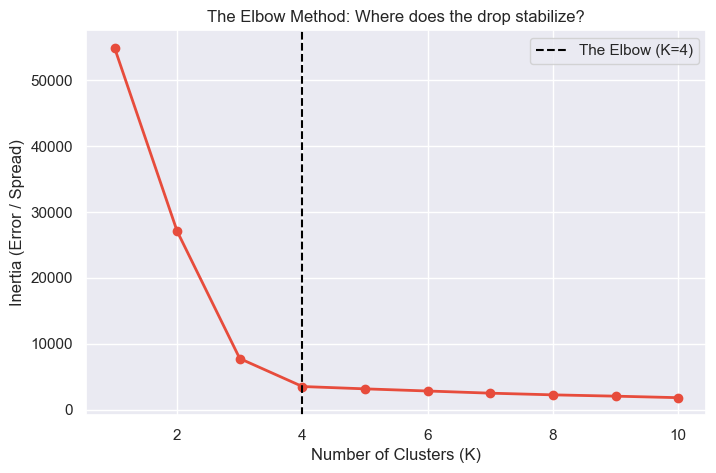

In [3]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    # We use n_init=10 to suppress warnings and ensure stability
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X)
    inertias.append(kmeans_test.inertia_) # Inertia is calculated for us automatically!

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', linewidth=2, color="#e74c3c")
plt.title("The Elbow Method: Where does the drop stabilize?")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Error / Spread)")
plt.axvline(4, color='black', linestyle='--', label='The Elbow (K=4)')
plt.legend()
plt.show()


### 🚀 Applying K-Means with K=4
The elbow is strongly marked at 4. Let's deploy the final algorithm and watch it extract the boundaries.

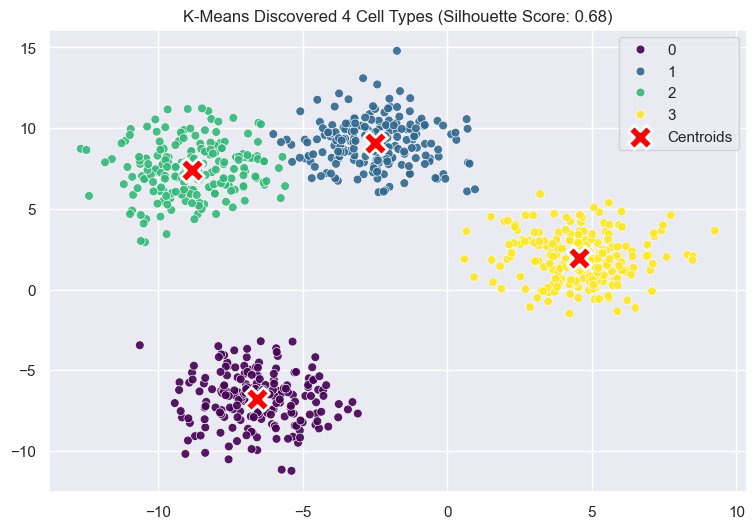

In [4]:
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
predicted_clusters = final_kmeans.fit_predict(X)
centroids = final_kmeans.cluster_centers_

# Calculate Silhouette Score (1.0 is perfect, 0.0 is overlapping, -1.0 is wrong)
# It measures how similar a cell is to its own cluster compared to neighboring clusters.
sil_score = silhouette_score(X, predicted_clusters)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=predicted_clusters, palette="viridis", s=40, alpha=0.9)

# Plot the literal mathematical centers the AI discovered!
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=300, color="red", edgecolor='white', linewidth=2, label='Centroids')
plt.title(f"K-Means Discovered 4 Cell Types (Silhouette Score: {sil_score:.2f})")
plt.legend()
plt.show()


---
## 🌳 Part 2: Hierarchical Clustering (Phylogenetics)

K-Means is incredibly fast, but it forces cells into circular blobs and REQUIRES you to guess `K` in advance.

**Hierarchical Clustering (Agglomerative)** builds a literal Evolutionary Tree (Dendrogram). This is heavily used in Bioinformatics to track viral mutations or protein domains.

**The Algorithm (Bottom-Up):**
1. **Start:** Every single cell is its own cluster. (800 cells = 800 clusters).
2. **Merge:** The AI finds the two cells that are mathematically identical (closest distance) and merges them into a "parent" cluster.
3. **Repeat:** It continually merges the closest clusters together over and over.
4. **Finish:** You end up with 1 massive biological root cluster at the very top.

### Linkage Logic (How to measure distance between whole groups?)
- You can't just draw a line between centers. So we use **Ward's Linkage**, which acts similarly to Variance.
- Ward mathematically merges clusters in a way that *minimizes* the total variance inside the newly formed group.

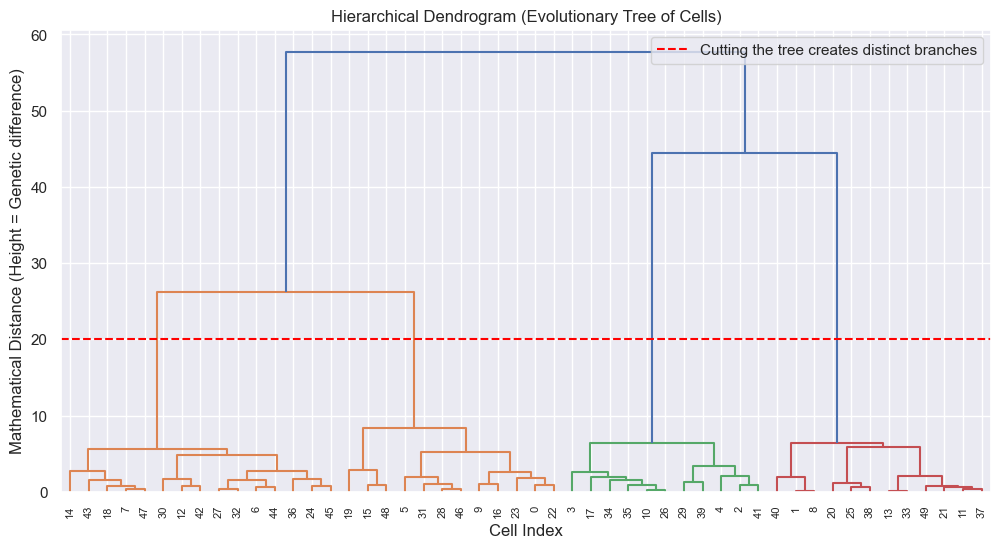

In [5]:
# To make the Dendrogram readable, let's take a small subset of 50 cells
X_subset = X[:50]

# Scipy's 'linkage' function performs the entire Bottom-Up merging logic!
evolutionary_tree = linkage(X_subset, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(evolutionary_tree)
plt.title("Hierarchical Dendrogram (Evolutionary Tree of Cells)")
plt.xlabel("Cell Index")
plt.ylabel("Mathematical Distance (Height = Genetic difference)")
plt.axhline(20, color='red', linestyle='--', label='Cutting the tree creates distinct branches')
plt.legend()
plt.show()

# Notice how the taller the vertical line, the more "different" the species are from each other.

### ✂️ Slicing the Tree
Once we look at the beautiful tree, we can take scissors and slice it horizontally. If we slice it at a specific height, we get exact branches (classes). 
Let's deploy this to `scikit-learn` on the full 800-cell dataset.

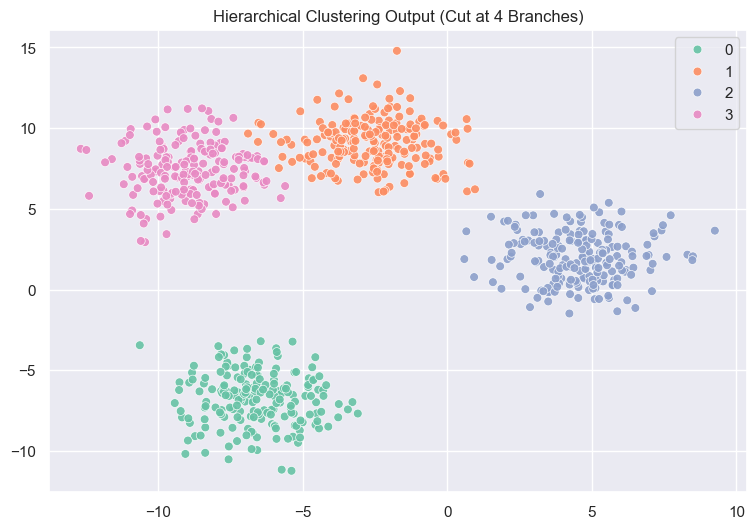

In [6]:
# Agglomerative Clustering is sklearn's version of Hierarchical.
hierarchical_ai = AgglomerativeClustering(n_clusters=4, linkage='ward')
hierarchical_labels = hierarchical_ai.fit_predict(X)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=hierarchical_labels, palette="Set2", s=40, alpha=0.9)
plt.title("Hierarchical Clustering Output (Cut at 4 Branches)")
plt.show()


---
## ⚖️ The Final Verdict: When to use which?

| Feature | K-Means | Hierarchical (Agglomerative) |
|---------|---------|------------------------------|
| **Speed** | ⚡ Extremely fast ($O(n)$) - Can handle Millions of Cells | 🐌 Very slow mathematically ($O(n^3)$) - Fails on massive datasets |
| **Shape Assumption** | Forces spherical/circular shapes. Fails on crescent moons. | Flexible depending on linkage. |
| **Choosing Clusters** | Must use Elbow method / Silhouette Score. | Look at the Dendrogram and visually slice the tree. |
| **Bioinformatics Use** | Bulk sorting of cells or gene profiles. | Phylogenetics, viral strains, and visualizing hierarchy. |
